# Temporal drift validation

How much does the model's predictive accuracy degrade as we move forward in time from the training data? Unlike `validation.ipynb` (which asks *"which model is best"* on a held-out test set), this notebook asks *"how quickly does that answer change"*.

**Split**: chronological 25/75. The oldest 25% of teams (by tournament date) form the training set; the newest 75% form the test set, sliced into equal-tournament-count windows. This deliberately under-trains compared to `validation.ipynb`'s 90/10 — absolute accuracy drops, but we get enough temporal range to see drift, shocks, and model-vs-model decay rates. Relative model differences are what matter, not absolute hit rates.

**Useful for**:
- Setting expectations on how often the model needs to be re-fit.
- Distinguishing **gradual drift** (slow metagame evolution → linear-ish decay) from **shocks** (a new top-tier team is discovered → sudden drop at one window).
- Cross-checking the headline cross-model numbers: if Phase 3's edge is purely a feature-richness effect, it should persist under temporal split; if it's partly a memorization artifact, it'll degrade faster than Phase 2.

**Models compared**: co-occurrence (control — also drifts, separates "model drifts" from "meta is just less predictable"), Phase 2 species Ising, Phase 3 pair Ising. Three models give the cleanest story without crowding the plot.

In [1]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from k2dex import helpers, tournament_ingest
from k2dex.constants import (
    DRIFT_TRAIN_FRAC, PHASE2_MIN_TEAM_COUNT,
    SPECIES_LR_C, SPECIES_ITEM_LR_C,
)
from k2dex.models import fit_pl_ising

tournaments = tournament_ingest.load_cached_tournaments()
print(f"tournaments:            {len(tournaments)}")
print(f"total team-appearances: {sum(len(t.teams) for t in tournaments)}")

tournaments:            167
total team-appearances: 19848


## Chronological 25/75 split

Oldest 25% of teams (by tournament boundary) → train. The remaining 75% is sliced into $N$ equal-tournament-count windows for per-window evaluation.

The low train fraction is deliberate: we sacrifice absolute accuracy to buy a wide temporal window. If the signal is robust enough to survive 25% training data, it's real; if model separation vanishes, that tells us the edge is fragile and data-hungry.

In [2]:
N_WINDOWS = 8

train_tournaments, test_tournaments = tournament_ingest.chronological_split(
    tournaments, train_frac=DRIFT_TRAIN_FRAC,
)

n_train_teams = sum(len(t.teams) for t in train_tournaments)
n_test_teams = sum(len(t.teams) for t in test_tournaments)
n_total = n_train_teams + n_test_teams

print(
    f"train (oldest {DRIFT_TRAIN_FRAC:.0%}): {len(train_tournaments)} tournaments, "
    f"{n_train_teams} teams ({n_train_teams/n_total:.1%})\n"
    f"  {train_tournaments[0].meta.date} -> {train_tournaments[-1].meta.date}\n"
    f"test  (newest {1 - DRIFT_TRAIN_FRAC:.0%}): {len(test_tournaments)} tournaments, "
    f"{n_test_teams} teams ({n_test_teams/n_total:.1%})\n"
    f"  {test_tournaments[0].meta.date} -> {test_tournaments[-1].meta.date}"
)

# Slice test tournaments into N equal-count windows; last absorbs remainder.
window_size = len(test_tournaments) // N_WINDOWS
windows = []
for i in range(N_WINDOWS):
    start = i * window_size
    end = (i + 1) * window_size if i < N_WINDOWS - 1 else len(test_tournaments)
    windows.append(test_tournaments[start:end])

print(f"\n{N_WINDOWS} test windows ({window_size} tournaments each):")
for i, w in enumerate(windows):
    teams_in_window = sum(len(t.teams) for t in w)
    print(
        f"  window {i}: {w[0].meta.date} -> {w[-1].meta.date}   "
        f"({len(w)} tournaments, {teams_in_window} teams)"
    )

train (oldest 25%): 51 tournaments, 4974 teams (25.1%)
  2026-04-09T16:00:00.000Z -> 2026-04-22T18:00:00.000Z
test  (newest 75%): 116 tournaments, 14874 teams (74.9%)
  2026-04-22T22:00:00.000Z -> 2026-06-02T22:30:00.000Z

8 test windows (14 tournaments each):
  window 0: 2026-04-22T22:00:00.000Z -> 2026-04-26T15:00:00.000Z   (14 tournaments, 7243 teams)
  window 1: 2026-04-26T17:00:00.000Z -> 2026-05-01T16:15:00.000Z   (14 tournaments, 879 teams)
  window 2: 2026-05-01T22:40:00.000Z -> 2026-05-04T22:30:00.000Z   (14 tournaments, 1193 teams)
  window 3: 2026-05-05T22:30:00.000Z -> 2026-05-10T21:00:00.000Z   (14 tournaments, 1123 teams)
  window 4: 2026-05-11T20:31:00.000Z -> 2026-05-17T05:00:00.000Z   (14 tournaments, 901 teams)
  window 5: 2026-05-17T15:00:00.000Z -> 2026-05-21T23:00:00.000Z   (14 tournaments, 657 teams)
  window 6: 2026-05-22T16:20:00.000Z -> 2026-05-25T23:30:00.000Z   (14 tournaments, 931 teams)
  window 7: 2026-05-26T16:00:00.000Z -> 2026-06-02T22:30:00.000Z   (18 

## Train-only vocabs

Both species and pair vocabs are built from the train set only. A species or `(species, item)` pair that only appears in future test tournaments is out-of-vocab — the model fit at time $t$ cannot know about a Pokémon that hadn't been used yet at time $t$.

In [3]:
train_teams_full = tournament_ingest.all_teams(train_tournaments)
train_teams = tournament_ingest.species_only_teams(train_teams_full)

# Species vocab
species_counts = Counter(name for team in train_teams for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
name_to_idx = {name: i for i, name in enumerate(vocab)}
V = len(vocab)

# Pair vocab
pair_counts = Counter(pair for team in train_teams_full for pair in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
V_pair = len(pair_vocab)

print(f"train species vocab: {V}")
print(f"train pair vocab:    {V_pair}")

train species vocab: 148
train pair vocab:    396


## Model fits (train-only)

In [4]:
def teams_to_matrix(teams, name_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for name in team:
            j = name_to_idx.get(name)
            if j is not None:
                X[ti, j] = 1
    return X


# Phase 2 (species) PL fit
X_train_species = teams_to_matrix(train_teams, name_to_idx, V).astype(np.int32)
J_species, h_species = fit_pl_ising(X_train_species, C=SPECIES_LR_C)
print(
    f"Phase 2 J range: "
    f"[{J_species[np.triu_indices(V, 1)].min():+.3f},"
    f" {J_species[np.triu_indices(V, 1)].max():+.3f}]"
)

# Phase 3 (pair) PL fit
X_train_pair = np.zeros((len(train_teams_full), V_pair), dtype=np.int32)
for ti, team in enumerate(train_teams_full):
    for pair in team:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_train_pair[ti, j] = 1

J_pair, h_pair = fit_pl_ising(X_train_pair, C=SPECIES_ITEM_LR_C)
print(
    f"Phase 3 J range: "
    f"[{J_pair[np.triu_indices(V_pair, 1)].min():+.3f},"
    f" {J_pair[np.triu_indices(V_pair, 1)].max():+.3f}]"
)

# Co-occurrence baseline
C_train = (X_train_species.T @ X_train_species).astype(np.float64)
np.fill_diagonal(C_train, 0.0)
print(f"C_train off-diag: max = {int(C_train.max())}, nnz = {int((C_train > 0).sum())}")

Phase 2 J range: [-2.480, +3.011]
Phase 3 J range: [-4.939, +3.860]
C_train off-diag: max = 1020, nnz = 9118


## Scoring functions

Same mean-field scoring as `validation.ipynb`. Phase 3 projects pair marginals to species marginals via the mutual-exclusion sum for fair cross-model comparison.

In [5]:
def score_cooccurrence(held_in_species_idx, *, C):
    return C[:, list(held_in_species_idx)].sum(axis=1)


def score_ising_meanfield(held_in_idx, *, J, h, n_iter=50, damp=0.5):
    V = J.shape[0]
    mu = np.full(V, 0.5)
    mu[list(held_in_idx)] = 1.0
    for _ in range(n_iter):
        logit = h + J @ mu
        mu_new = 1.0 / (1.0 + np.exp(-logit))
        mu_new[list(held_in_idx)] = 1.0
        mu = damp * mu + (1 - damp) * mu_new
    return mu


def hit_rate_at_k(ranks, K):
    return float((ranks <= K).mean())


def mrr(ranks):
    return float((1.0 / ranks).mean())

## Per-window leave-1-out evaluation

For each window: filter test teams to those with all members in both train-only vocabs (so all three models can score them), hold out one species, compute top-K hit rate and MRR.

In [6]:
SEED = 42
DRIFT_K = 1
DRIFT_TOP_K = [1, 5, 10]

# Species -> list of pair indices (for Phase 3 projection)
species_to_pair_idxs: dict[str, list[int]] = {}
for i, (sp, _) in enumerate(pair_vocab):
    species_to_pair_idxs.setdefault(sp, []).append(i)

model_names = ["co-occurrence", "Ising species", "Ising item-pair"]
metrics = {
    name: {"hit_rate": {K: [] for K in DRIFT_TOP_K}, "mrr": [], "n_teams": []}
    for name in model_names
}
window_labels = []
window_dates_center = []

rng = np.random.default_rng(SEED)

for w_idx, window_tournaments in enumerate(windows):
    window_teams_full = tournament_ingest.all_teams(window_tournaments)
    in_vocab_window = []
    for team in window_teams_full:
        if len(team) != 6:
            continue
        if len({s for s, _ in team}) != 6:
            continue
        if not all(s in name_to_idx for s, _ in team):
            continue
        if not all(p in pair_to_idx for p in team):
            continue
        in_vocab_window.append(team)

    label = f"{window_tournaments[0].meta.date[:10]}\n{window_tournaments[-1].meta.date[:10]}"
    window_labels.append(label)
    window_dates_center.append(window_tournaments[len(window_tournaments) // 2].meta.date[:10])

    per_window_ranks = {name: [] for name in model_names}

    for team in in_vocab_window:
        members = sorted(team, key=lambda p: p[0])
        species_idxs = np.array([name_to_idx[s] for s, _ in members])
        pair_idxs = np.array([pair_to_idx[p] for p in members])

        held_out_pos = rng.choice(6, size=DRIFT_K, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_out_species_idx = species_idxs[held_out_pos]
        held_in_species_idx = species_idxs[held_in_pos]
        held_in_pair_idx = pair_idxs[held_in_pos]

        # Species-vocab scorers (co-occurrence + Phase 2 Ising)
        for name, score_arr in (
            ("co-occurrence", score_cooccurrence(held_in_species_idx, C=C_train)),
            ("Ising species", score_ising_meanfield(held_in_species_idx, J=J_species, h=h_species)),
        ):
            scores = score_arr.astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            per_window_ranks[name].append(rank_of[held_out_species_idx])

        # Phase 3: pair-MF projected to species via mutual-exclusion sum
        pair_marginals = score_ising_meanfield(held_in_pair_idx, J=J_pair, h=h_pair)
        species_scores_p3 = np.zeros(V)
        for j_pair, (sp, _) in enumerate(pair_vocab):
            s_idx = name_to_idx.get(sp)
            if s_idx is None:
                continue
            species_scores_p3[s_idx] += pair_marginals[j_pair]
        species_scores_p3[held_in_species_idx] = -np.inf
        order = np.argsort(-species_scores_p3)
        rank_of = np.empty(V, dtype=np.int64)
        rank_of[order] = np.arange(1, V + 1)
        per_window_ranks["Ising item-pair"].append(rank_of[held_out_species_idx])

    for name in model_names:
        ranks_arr = np.array(per_window_ranks[name])
        if len(ranks_arr) == 0:
            for K in DRIFT_TOP_K:
                metrics[name]["hit_rate"][K].append(np.nan)
            metrics[name]["mrr"].append(np.nan)
            metrics[name]["n_teams"].append(0)
            continue
        for K in DRIFT_TOP_K:
            metrics[name]["hit_rate"][K].append(float((ranks_arr <= K).mean()))
        metrics[name]["mrr"].append(float((1.0 / ranks_arr).mean()))
        metrics[name]["n_teams"].append(len(ranks_arr))

    print(
        f"window {w_idx} ({label.replace(chr(10), ' -> ')}): "
        f"{len(in_vocab_window):>4} in-vocab teams / {len(window_teams_full):>4} total"
    )

window 0 (2026-04-22 -> 2026-04-26): 5430 in-vocab teams / 7243 total
window 1 (2026-04-26 -> 2026-05-01):  673 in-vocab teams /  879 total
window 2 (2026-05-01 -> 2026-05-04):  901 in-vocab teams / 1193 total
window 3 (2026-05-05 -> 2026-05-10):  846 in-vocab teams / 1123 total
window 4 (2026-05-11 -> 2026-05-17):  663 in-vocab teams /  901 total
window 5 (2026-05-17 -> 2026-05-21):  511 in-vocab teams /  657 total
window 6 (2026-05-22 -> 2026-05-25):  681 in-vocab teams /  931 total
window 7 (2026-05-26 -> 2026-06-02): 1414 in-vocab teams / 1947 total


## Drift curves

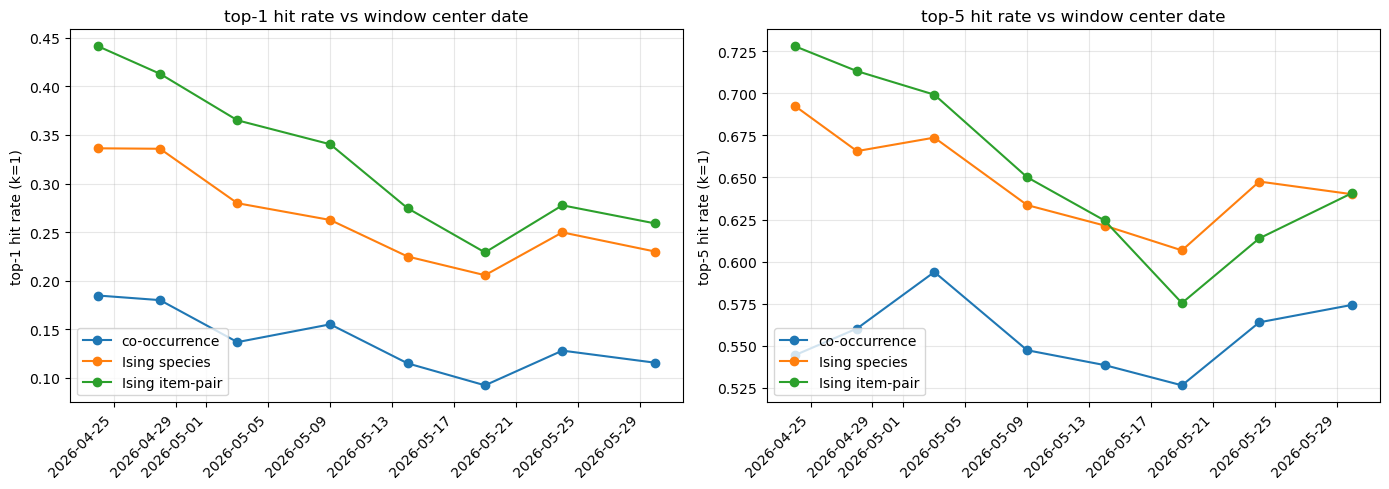

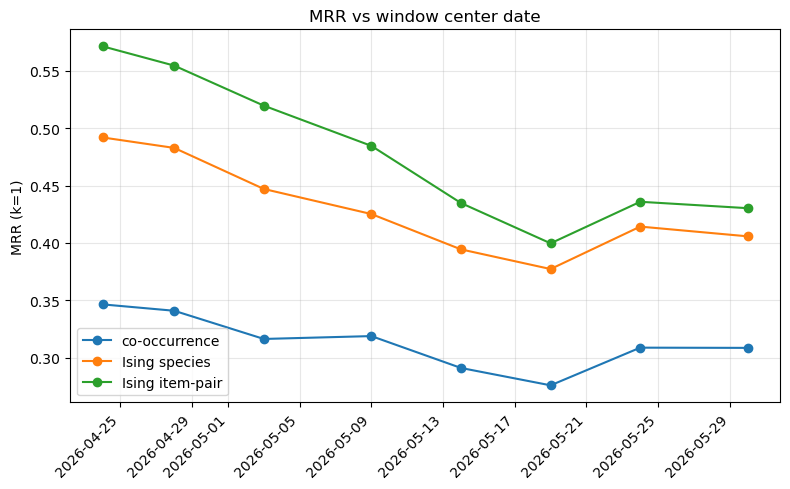

In [7]:
from datetime import datetime

import matplotlib.dates as mdates

x_dates = [datetime.strptime(d, "%Y-%m-%d") for d in window_dates_center]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, K in zip(axes, [1, 5]):
    for name in model_names:
        ax.plot(x_dates, metrics[name]["hit_rate"][K], marker="o", label=name)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate(rotation=45, ha="right")
    ax.set_ylabel(f"top-{K} hit rate (k=1)")
    ax.set_title(f"top-{K} hit rate vs window center date")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
for name in model_names:
    ax2.plot(x_dates, metrics[name]["mrr"], marker="o", label=name)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig2.autofmt_xdate(rotation=45, ha="right")
ax2.set_ylabel("MRR (k=1)")
ax2.set_title("MRR vs window center date")
ax2.grid(alpha=0.3)
ax2.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Per-window summary

In [8]:
print(f"{'window':>6}  {'date range':<25}  {'n_teams':>7}  ", end="")
for name in model_names:
    print(f"  {name:>18} top-1", end="")
print()
print("-" * 120)
for i in range(N_WINDOWS):
    date_range = window_labels[i].replace('\n', ' -> ')
    n = metrics[model_names[0]]["n_teams"][i]
    print(f"{i:>6}  {date_range:<25}  {n:>7}  ", end="")
    for name in model_names:
        hr = metrics[name]["hit_rate"][1][i]
        print(f"  {hr:>22.1%}", end="")
    print()

window  date range                 n_teams         co-occurrence top-1       Ising species top-1     Ising item-pair top-1
------------------------------------------------------------------------------------------------------------------------
     0  2026-04-22 -> 2026-04-26      5430                     18.5%                   33.6%                   44.1%
     1  2026-04-26 -> 2026-05-01       673                     18.0%                   33.6%                   41.3%
     2  2026-05-01 -> 2026-05-04       901                     13.7%                   28.0%                   36.5%
     3  2026-05-05 -> 2026-05-10       846                     15.5%                   26.2%                   34.0%
     4  2026-05-11 -> 2026-05-17       663                     11.5%                   22.5%                   27.5%
     5  2026-05-17 -> 2026-05-21       511                      9.2%                   20.5%                   22.9%
     6  2026-05-22 -> 2026-05-25       681            

## Interpretation

What the curves typically tell us:

- **All three lines drift downward together**: the meta is genuinely shifting, and *no* fixed model captures the new state. Distance between lines tells you which model degrades fastest.
- **A sharp drop in one window**: candidate for a meta shock — a new team archetype was discovered that hadn't shown up enough in training to register. Cross-reference the dates against community events / format announcements.
- **Ising species drifts faster than Ising item-pair (or vice versa)**: gap-stability tells you which feature granularity is more robust to meta evolution. Item-pair degrading faster would be a memorization signal (more features, less per-feature data, more capacity to overfit to specific roster choices that don't survive). Species degrading faster would mean item-pair is capturing more time-stable structure.
- **All three lines hold roughly flat**: meta is stable across the test window and the train parameters generalize fine. Less interesting as a result but a useful null — confirms no systematic harness bug producing apparent decay.
- **Co-occurrence drifts least**: counts are robust summary statistics; the Ising models' edge comes from fitting *patterns* that are more sensitive to which patterns happen to be in style. This would suggest the Ising win is more "compression of current meta" than "discovery of timeless structure."

To go further: re-cut the experiment with the train half ending at a *known* event (a major regulation update, a Pokémon Champions patch, a high-profile tournament result going viral) and check whether the drop in the first post-event window is larger than the drift between adjacent windows otherwise. That's the cleanest test of "model detects shock vs. drift."

## Training window sweep

Does including the earliest (discovery-meta) tournaments help or hurt the production model? The format's details weren't announced in advance, so the first weeks of tournament data capture players figuring out the meta on the fly — a fundamentally different distribution from the settled meta.

**Setup**: hold the test set fixed (newest ~10% of the full corpus, same as `validation.ipynb`). Subdivide the remaining train-eligible tournaments into $N$ chronological slices. Evaluate $N$ models, each trained on a different start point but the same end point:

- Model 1: train on slices 1–N (all train data)
- Model 2: train on slices 2–N (drop oldest slice)
- ...
- Model N: train on slice N only (most recent train data only)

If accuracy peaks somewhere in the middle — not at "use everything" — the early data is actively dilutive and a narrower production window would improve the model.

In [9]:
from k2dex.constants import VALIDATION_TEAM_FRAC_TEST

# Fixed test set: newest ~10% of the full corpus.
train_eligible, test_fixed_tournaments = tournament_ingest.chronological_split(
    tournaments, train_frac=1.0 - VALIDATION_TEAM_FRAC_TEST,
)

train_eligible_full = tournament_ingest.all_teams(train_eligible)
train_eligible_species = tournament_ingest.species_only_teams(train_eligible_full)
test_fixed_full = tournament_ingest.all_teams(test_fixed_tournaments)

# Subdivide train-eligible tournaments into N_SLICES chronological slices.
N_SLICES = 5
slice_size = len(train_eligible) // N_SLICES
train_slices = []
for i in range(N_SLICES):
    start = i * slice_size
    end = (i + 1) * slice_size if i < N_SLICES - 1 else len(train_eligible)
    train_slices.append(train_eligible[start:end])

# Vocab built once from ALL train-eligible data — constant across sweep points.
# This keeps the test set and feature indices identical for every model.
sw_sp_counts = Counter(name for team in train_eligible_species for name in team)
sw_vocab = sorted(name for name, c in sw_sp_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
sw_n2i = {name: i for i, name in enumerate(sw_vocab)}
sw_V = len(sw_vocab)

sw_pair_counts = Counter(pair for team in train_eligible_full for pair in team)
sw_pair_vocab = sorted(
    (p for p, c in sw_pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
sw_p2i = {p: i for i, p in enumerate(sw_pair_vocab)}
sw_Vp = len(sw_pair_vocab)

sw_sp2pairs: dict[str, list[int]] = {}
for i, (sp, _) in enumerate(sw_pair_vocab):
    sw_sp2pairs.setdefault(sp, []).append(i)

# Fixed in-vocab test set (same for every sweep point).
sw_test_iv = []
for team in test_fixed_full:
    if len(team) != 6:
        continue
    if len({s for s, _ in team}) != 6:
        continue
    if not all(s in sw_n2i for s, _ in team):
        continue
    if not all(p in sw_p2i for p in team):
        continue
    sw_test_iv.append(team)

print(f"test set: {len(test_fixed_full)} total, {len(sw_test_iv)} in-vocab (fixed across sweep)")
print(f"vocab: {sw_V} species, {sw_Vp} pairs (from full train-eligible)")
print(f"\ntrain-eligible: {len(train_eligible)} tournaments, {N_SLICES} slices:")
for i, s in enumerate(train_slices):
    n = sum(len(t.teams) for t in s)
    print(f"  slice {i}: {s[0].meta.date} -> {s[-1].meta.date}  ({len(s)} tournaments, {n} teams)")

test set: 1947 total, 1790 in-vocab (fixed across sweep)
vocab: 192 species, 728 pairs (from full train-eligible)

train-eligible: 149 tournaments, 5 slices:
  slice 0: 2026-04-09T16:00:00.000Z -> 2026-04-17T18:00:00.000Z  (29 tournaments, 2894 teams)
  slice 1: 2026-04-17T19:00:00.000Z -> 2026-04-24T16:25:00.000Z  (29 tournaments, 2566 teams)
  slice 2: 2026-04-24T22:40:00.000Z -> 2026-05-03T13:00:00.000Z  (29 tournaments, 8487 teams)
  slice 3: 2026-05-03T15:00:00.000Z -> 2026-05-15T12:00:00.000Z  (29 tournaments, 1926 teams)
  slice 4: 2026-05-15T17:00:00.000Z -> 2026-05-25T23:30:00.000Z  (33 tournaments, 2028 teams)


In [10]:
SWEEP_SEED = 42
SWEEP_K = 1
SWEEP_TOP_K = [1, 5, 10]

sweep_model_names = ["co-occurrence", "Ising species", "Ising item-pair"]
sweep_results = {
    name: {"hit_rate": {K: [] for K in SWEEP_TOP_K}, "mrr": [], "label": [], "n_train": []}
    for name in sweep_model_names
}

for start_slice in range(N_SLICES):
    # Train on slices [start_slice .. N_SLICES-1], using the fixed vocab.
    sw_train_tournaments = [t for s in train_slices[start_slice:] for t in s]
    sw_train_full = tournament_ingest.all_teams(sw_train_tournaments)
    sw_train_species = tournament_ingest.species_only_teams(sw_train_full)

    # Build feature matrices against the FIXED vocab.
    sw_X_sp = teams_to_matrix(sw_train_species, sw_n2i, sw_V).astype(np.int32)
    sw_J, sw_h = fit_pl_ising(sw_X_sp, C=SPECIES_LR_C)

    sw_X_pair = np.zeros((len(sw_train_full), sw_Vp), dtype=np.int32)
    for ti, team in enumerate(sw_train_full):
        for pair in team:
            j = sw_p2i.get(pair)
            if j is not None:
                sw_X_pair[ti, j] = 1
    sw_Jp, sw_hp = fit_pl_ising(sw_X_pair, C=SPECIES_ITEM_LR_C)

    sw_C = (sw_X_sp.T @ sw_X_sp).astype(np.float64)
    np.fill_diagonal(sw_C, 0.0)

    # Evaluate on the FIXED in-vocab test set.
    rng_sw = np.random.default_rng(SWEEP_SEED)
    per_model_ranks = {name: [] for name in sweep_model_names}

    for team in sw_test_iv:
        members = sorted(team, key=lambda p: p[0])
        sp_idxs = np.array([sw_n2i[s] for s, _ in members])
        pair_idxs = np.array([sw_p2i[p] for p in members])

        held_out_pos = rng_sw.choice(6, size=SWEEP_K, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_out_sp = sp_idxs[held_out_pos]
        held_in_sp = sp_idxs[held_in_pos]
        held_in_pair = pair_idxs[held_in_pos]

        for name, score_arr in (
            ("co-occurrence", score_cooccurrence(held_in_sp, C=sw_C)),
            ("Ising species", score_ising_meanfield(held_in_sp, J=sw_J, h=sw_h)),
        ):
            scores = score_arr.astype(np.float64).copy()
            scores[held_in_sp] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(sw_V, dtype=np.int64)
            rank_of[order] = np.arange(1, sw_V + 1)
            per_model_ranks[name].append(rank_of[held_out_sp])

        pair_marg = score_ising_meanfield(held_in_pair, J=sw_Jp, h=sw_hp)
        sp_scores_p3 = np.zeros(sw_V)
        for j_pair, (sp, _) in enumerate(sw_pair_vocab):
            s_idx = sw_n2i.get(sp)
            if s_idx is not None:
                sp_scores_p3[s_idx] += pair_marg[j_pair]
        sp_scores_p3[held_in_sp] = -np.inf
        order = np.argsort(-sp_scores_p3)
        rank_of = np.empty(sw_V, dtype=np.int64)
        rank_of[order] = np.arange(1, sw_V + 1)
        per_model_ranks["Ising item-pair"].append(rank_of[held_out_sp])

    label = f"{sw_train_tournaments[0].meta.date[:10]}+"
    print(
        f"start={label}  train={len(sw_train_full):>5} teams  "
        f"test_iv={len(sw_test_iv):>4} (fixed)"
    )

    for name in sweep_model_names:
        ranks_arr = np.array(per_model_ranks[name])
        for K in SWEEP_TOP_K:
            sweep_results[name]["hit_rate"][K].append(float((ranks_arr <= K).mean()))
        sweep_results[name]["mrr"].append(float((1.0 / ranks_arr).mean()))
        sweep_results[name]["label"].append(label)
        sweep_results[name]["n_train"].append(len(sw_train_full))

start=2026-04-09+  train=17901 teams  test_iv=1790 (fixed)
start=2026-04-17+  train=15007 teams  test_iv=1790 (fixed)
start=2026-04-24+  train=12441 teams  test_iv=1790 (fixed)
start=2026-05-03+  train= 3954 teams  test_iv=1790 (fixed)
start=2026-05-15+  train= 2028 teams  test_iv=1790 (fixed)


## Window sweep results

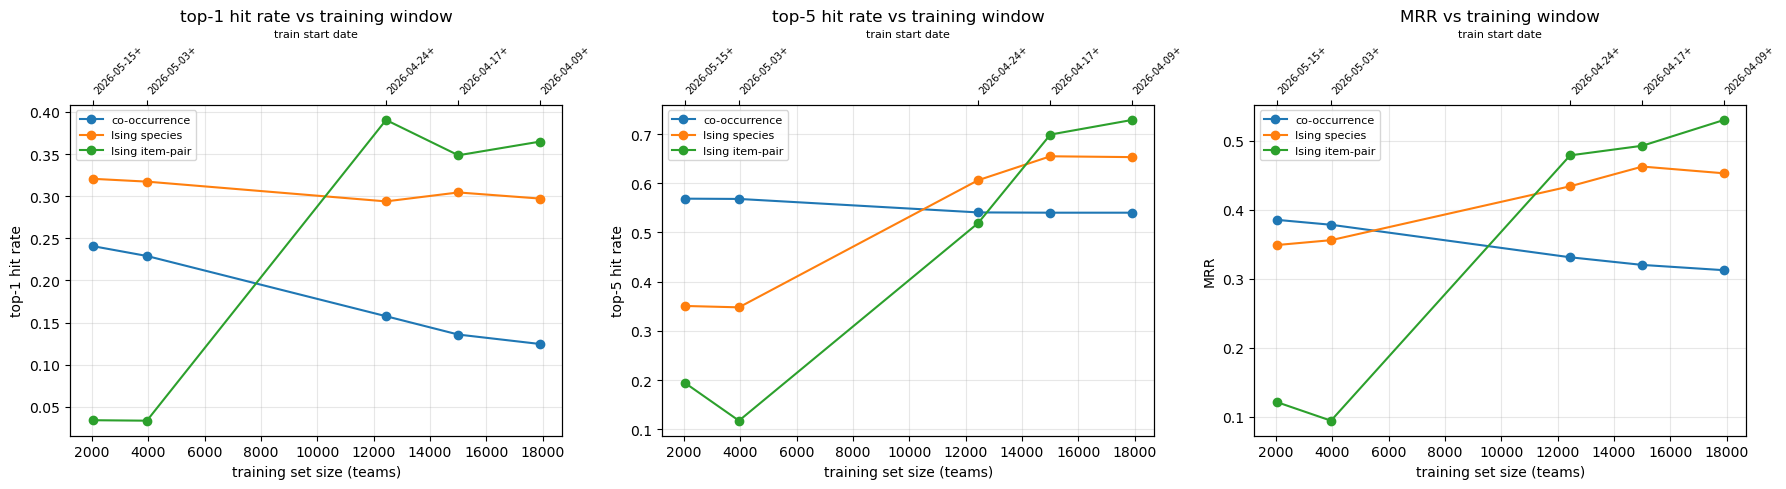

start date     n_train       co-occurrence top-1  MRR       Ising species top-1  MRR     Ising item-pair top-1  MRR
------------------------------------------------------------------------------------------------------------------------
2026-04-09+      17901               12.5% 0.312               29.7% 0.453               36.5% 0.530
2026-04-17+      15007               13.6% 0.320               30.4% 0.462               34.9% 0.492
2026-04-24+      12441               15.8% 0.331               29.4% 0.434               39.1% 0.478
2026-05-03+       3954               22.9% 0.378               31.7% 0.356                3.4% 0.094
2026-05-15+       2028               24.1% 0.385               32.1% 0.349                3.4% 0.121


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = sweep_results[sweep_model_names[0]]["label"]
n_trains = sweep_results[sweep_model_names[0]]["n_train"]
x_train = np.array(n_trains)

for ax, (metric_key, metric_label) in zip(axes, [
    (("hit_rate", 1), "top-1 hit rate"),
    (("hit_rate", 5), "top-5 hit rate"),
    ("mrr", "MRR"),
]):
    for name in sweep_model_names:
        if isinstance(metric_key, tuple):
            y = sweep_results[name][metric_key[0]][metric_key[1]]
        else:
            y = sweep_results[name][metric_key]
        ax.plot(x_train, y, marker="o", label=name)
    ax.set_xlabel("training set size (teams)")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} vs training window")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    # Add start-date labels on top axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(x_train)
    ax2.set_xticklabels(labels, fontsize=7, rotation=45, ha="left")
    ax2.set_xlabel("train start date", fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'start date':<14} {'n_train':>7}", end="")
for name in sweep_model_names:
    print(f"  {name:>18} top-1  MRR", end="")
print()
print("-" * 120)
for i in range(len(labels)):
    print(f"{labels[i]:<14} {n_trains[i]:>7}", end="")
    for name in sweep_model_names:
        hr = sweep_results[name]["hit_rate"][1][i]
        m = sweep_results[name]["mrr"][i]
        print(f"  {hr:>18.1%} {m:>.3f}", end="")
    print()

## Window sweep interpretation

Read the curve left-to-right (most data → least data). Two competing effects:

- **More data helps**: larger training sets give more precise coupling estimates, especially for rarer species/item pairs. This pushes accuracy up as training size grows.
- **Stale data hurts**: early-format tournaments capture a discovery meta that doesn't match the settled meta the test set comes from. This pushes accuracy down as the training window reaches further back.

If accuracy peaks at an intermediate training size (not the largest), the staleness effect dominates the precision effect — and the production model should use a narrower, more recent training window. The peak location tells you roughly where to draw the line.

If accuracy monotonically increases with training size, the early data is noisy but not *harmful* — more data always helps, and there's no reason to trim.